# Cải tiến TransUNet — Foreground-Aware Logit Masking (Anatomy Prior)

**Tên mô hình mới: `TransUNet_FGMask`**

## Vấn đề: Self-Attention bị "loãng" vì mất cân bằng dữ liệu
Ở `data.ipynb` ta thấy **Background chiếm >80% pixel** (≈554 triệu px), trong khi cơ quan nhỏ
như **Stomach chỉ 651K px**, **R.Kidney 245K px**. Trong TransUNet, mỗi token (patch 16×16)
phải tính điểm tương đồng với **toàn bộ 196 token** qua \( \mathrm{Softmax}(QK^T/\sqrt d)V \).

Vì có hàng chục token Background tương đồng với token cơ quan, **Softmax** chuẩn hoá tổng = 1
→ token Dạ dày **phân bố chú ý quá dàn trải cho nền**, không học tốt quan hệ giải phẫu giữa
các cơ quan (Dạ dày dưới Gan, cạnh Lách...). Cơ quan nhỏ vì thế bị "nuốt chửng".

## Giải pháp: tiêm **Anatomy Prior** vào logit (trước Softmax)
**Bước 1 — Anatomy Prior Map.** Lấy CNN feature \(14\times14\times1024\) (ngay trước ViT),
cho qua **Conv2d(1024, 1, kernel=1)** + **Sigmoid** → bản đồ mềm \(M \in [0,1]^{14\times14}\):
gần 1 ở cơ quan, gần 0 ở nền.

**Bước 2 — Logit Masking.** Cộng prior vào logit attention (KHÔNG nhân vào V):
\[
\mathrm{Attention}_{new}(Q,K,V) = \mathrm{Softmax}\!\Big(\tfrac{QK^T}{\sqrt d} + \alpha\cdot\log(M+\epsilon)\Big)V
\]
Token nền \(M\!\approx\!0 \Rightarrow \log\!\approx\!-\infty\) → sau Softmax trọng số ≈ 0%.
Token cơ quan \(M\!\approx\!1 \Rightarrow \log 1 = 0\) → giữ nguyên. \(\epsilon=10^{-6}\).

**Bước 3 — Tự điều chỉnh.** \(\alpha\) là **learnable scalar**, khởi tạo **0**:
- Epoch đầu CNN chưa tốt → model tự giữ \(\alpha\!\approx\!0\) (≈ TransUNet gốc, không rủi ro).
- Khi prior map chính xác hơn → model tự **tăng \(\alpha\)** để kích hoạt lọc Background.

## So sánh
- Baseline: **TransUNet (gốc)** & **R50-U-Net** (số liệu từ `demo.ipynb`, cùng tập test 12 volume).
- Notebook chạy trên **Google Colab (GPU)**, dữ liệu **Synapse** lấy y như cũ (Kaggle).
- Cùng pipeline train (`trainer_synapse`: 0.5·CE + 0.5·Dice, SGD, poly-LR) để **công bằng**.


## 1. Thiết lập môi trường Colab
Cài thư viện, clone repo TransUNet, tải Synapse từ Kaggle và trọng số ViT pretrained
(giống `demo.ipynb` / `attentiongate.ipynb` — chỉ để Colab có đủ dữ liệu chạy).

In [1]:
# === 1. INSTALL ===
!pip install -q ml-collections medpy SimpleITK tensorboardX h5py scipy matplotlib kaggle

# === 2. CLONE REPO ===
!rm -rf /content/TransUNet
!git clone https://github.com/Beckschen/TransUNet.git

# === 3. KAGGLE CREDENTIALS ===
import os, shutil
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'wb') as f:
    f.write(b'{"username":"ynzboyvt","key":"KGAT_e1129cdba4fc46f3eb3dfdfb0c7b7f9a"}')
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

# === 4. DOWNLOAD DATA (Synapse - giong data.ipynb) ===
!kaggle datasets download -d dogcdt/synapse -p /content/synapse_zip
!unzip -q -o /content/synapse_zip/*.zip -d /content/synapse_temp

# === 5. MOVE DATA ===
for folder in ['train_npz', 'test_vol_h5']:
    src = f'/content/synapse_temp/Synapse/{folder}'
    dst = f'/content/data/Synapse/{folder}'
    os.makedirs(dst, exist_ok=True)
    for fname in os.listdir(src):
        shutil.move(os.path.join(src, fname), os.path.join(dst, fname))
!rm -rf /content/synapse_zip /content/synapse_temp

# === 6. VIT PRETRAINED WEIGHTS ===
os.makedirs('/content/model/vit_checkpoint/imagenet21k', exist_ok=True)
!wget -q https://storage.googleapis.com/vit_models/imagenet21k/R50+ViT-B_16.npz \
    -O /content/model/vit_checkpoint/imagenet21k/R50+ViT-B_16.npz

# === 7. FIX CONFIG PATH ===
cfg = '/content/TransUNet/networks/vit_seg_configs.py'
with open(cfg, 'r') as f: txt = f.read()
txt = txt.replace("'../model/vit_checkpoint/imagenet21k/", "'/content/model/vit_checkpoint/imagenet21k/")
with open(cfg, 'w') as f: f.write(txt)

# === 8. CHECK ===
t = len(os.listdir('/content/data/Synapse/train_npz'))
e = len(os.listdir('/content/data/Synapse/test_vol_h5'))
wf = '/content/model/vit_checkpoint/imagenet21k/R50+ViT-B_16.npz'
w = os.path.exists(wf) and os.path.getsize(wf) > 1_000_000
gpu = !nvidia-smi --query-gpu=name --format=csv,noheader
print(f"\nGPU: {gpu[0] if gpu else 'NONE!'}")
print(f"Train: {t} files {'OK' if t>0 else 'MISSING'}")
print(f"Test:  {e} files {'OK' if e>0 else 'MISSING'}")
print(f"ViT:   {'OK' if w else 'MISSING'}")
print(f"\n{'SAN SANG TRAIN!' if t>0 and e>0 and w else 'CON THIEU!'}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 13.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 8.6 MB/s eta 0:00:00
Cloning into 'TransUNet'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 128 (delta 71), reused 48 (delta 48), pack-reused 40 (from 1)
Receiving objects: 100% (128/128), 47.00 KiB | 15.67 MiB/s, done.
Resolving deltas: 100% (71/71), done.
Dataset URL: https://www.kaggle.com/datasets/dogcdt/synapse
License(s): unknown
100% 607M/607M [00:39<00:00, 16.3MB/s]


GPU: NVIDIA A100-SXM4-80GB
Train: 2211 files OK
Test:  12 files OK
ViT:   OK

SAN SANG TRAIN!


In [2]:
%cd /content/TransUNet
# Tao __init__.py cho cac package de import duoc
!touch datasets/__init__.py
!touch networks/__init__.py
!python -c "from datasets.dataset_synapse import Synapse_dataset; print('Import OK!')"


/content/TransUNet
Import OK!


## 2. Định nghĩa kiến trúc `TransUNet_FGMask`

File mới `networks/vit_seg_fgmask.py` **tái sử dụng toàn bộ** ResNet-50 + decoder gốc, chỉ
**sửa phần self-attention của ViT** để tiêm Anatomy Prior vào logit.

| Thành phần | Thay đổi so với gốc |
|------------|---------------------|
| `Embeddings` | Thêm `Conv2d(1024,1,1)` + Sigmoid → prior map `M ∈ [0,1]^196` từ CNN feature |
| `Attention` | `scores = QK^T/√d + α·log(M+ε)` **trước** Softmax (mask theo token *key*) |
| `Transformer` | Thêm `fg_alpha` (learnable scalar, init 0); tính `attn_bias` 1 lần, truyền vào mọi block |
| `VisionTransformerFG` | Kế thừa `VisionTransformer` → **dùng lại `load_from` & `forward`** (drop-in cho trainer gốc) |

**Quan trọng:**
- `M` được tính **1 lần** từ CNN feature, dùng chung cho cả 12 lớp Transformer.
- `attn_bias` shape `(B,1,1,N)` → broadcast: mỗi *query* sẽ giảm chú ý tới các *key* là nền.
- `fg_conv` & `fg_alpha` **train từ đầu** (không nằm trong pretrained); phần còn lại load ViT.
- `forward` trả về **chỉ logits** → tương thích hoàn toàn `trainer_synapse` (so sánh công bằng).


In [3]:
%%writefile /content/TransUNet/networks/vit_seg_fgmask.py
# coding=utf-8
"""TransUNet + Foreground-Aware Logit Masking (Anatomy Prior) trong self-attention ViT."""
import copy
import math
from os.path import join as pjoin

import torch
import torch.nn as nn
from torch.nn import Dropout, Softmax, Linear, Conv2d, LayerNorm
from torch.nn.modules.utils import _pair

from .vit_seg_modeling_resnet_skip import ResNetV2
from .vit_seg_modeling import (
    VisionTransformer, Mlp, DecoderCup, SegmentationHead, np2th,
    ATTENTION_Q, ATTENTION_K, ATTENTION_V, ATTENTION_OUT,
    FC_0, FC_1, ATTENTION_NORM, MLP_NORM,
)


class Attention(nn.Module):
    """Multi-head self-attention + Foreground-Aware Logit Bias."""
    def __init__(self, config, vis):
        super().__init__()
        self.vis = vis
        self.num_attention_heads = config.transformer["num_heads"]
        self.attention_head_size = int(config.hidden_size / self.num_attention_heads)
        self.all_head_size = self.num_attention_heads * self.attention_head_size
        self.query = Linear(config.hidden_size, self.all_head_size)
        self.key = Linear(config.hidden_size, self.all_head_size)
        self.value = Linear(config.hidden_size, self.all_head_size)
        self.out = Linear(config.hidden_size, config.hidden_size)
        self.attn_dropout = Dropout(config.transformer["attention_dropout_rate"])
        self.proj_dropout = Dropout(config.transformer["attention_dropout_rate"])
        self.softmax = Softmax(dim=-1)

    def transpose_for_scores(self, x):
        new_x_shape = x.size()[:-1] + (self.num_attention_heads, self.attention_head_size)
        x = x.view(*new_x_shape)
        return x.permute(0, 2, 1, 3)

    def forward(self, hidden_states, attn_bias=None):
        mixed_query_layer = self.query(hidden_states)
        mixed_key_layer = self.key(hidden_states)
        mixed_value_layer = self.value(hidden_states)
        query_layer = self.transpose_for_scores(mixed_query_layer)
        key_layer = self.transpose_for_scores(mixed_key_layer)
        value_layer = self.transpose_for_scores(mixed_value_layer)
        attention_scores = torch.matmul(query_layer, key_layer.transpose(-1, -2))
        attention_scores = attention_scores / math.sqrt(self.attention_head_size)
        # ===== Foreground-Aware Logit Masking =====
        # attn_bias = alpha * log(M + eps), shape (B,1,1,N) -> cong vao logit TRUOC softmax.
        if attn_bias is not None:
            attention_scores = attention_scores + attn_bias
        attention_probs = self.softmax(attention_scores)
        weights = attention_probs if self.vis else None
        attention_probs = self.attn_dropout(attention_probs)
        context_layer = torch.matmul(attention_probs, value_layer)
        context_layer = context_layer.permute(0, 2, 1, 3).contiguous()
        new_context_layer_shape = context_layer.size()[:-2] + (self.all_head_size,)
        context_layer = context_layer.view(*new_context_layer_shape)
        attention_output = self.out(context_layer)
        attention_output = self.proj_dropout(attention_output)
        return attention_output, weights


class Block(nn.Module):
    def __init__(self, config, vis):
        super().__init__()
        self.hidden_size = config.hidden_size
        self.attention_norm = LayerNorm(config.hidden_size, eps=1e-6)
        self.ffn_norm = LayerNorm(config.hidden_size, eps=1e-6)
        self.ffn = Mlp(config)
        self.attn = Attention(config, vis)

    def forward(self, x, attn_bias=None):
        h = x
        x = self.attention_norm(x)
        x, weights = self.attn(x, attn_bias)
        x = x + h
        h = x
        x = self.ffn_norm(x)
        x = self.ffn(x)
        x = x + h
        return x, weights

    def load_from(self, weights, n_block):
        ROOT = f"Transformer/encoderblock_{n_block}"
        with torch.no_grad():
            query_weight = np2th(weights[pjoin(ROOT, ATTENTION_Q, "kernel")]).view(self.hidden_size, self.hidden_size).t()
            key_weight = np2th(weights[pjoin(ROOT, ATTENTION_K, "kernel")]).view(self.hidden_size, self.hidden_size).t()
            value_weight = np2th(weights[pjoin(ROOT, ATTENTION_V, "kernel")]).view(self.hidden_size, self.hidden_size).t()
            out_weight = np2th(weights[pjoin(ROOT, ATTENTION_OUT, "kernel")]).view(self.hidden_size, self.hidden_size).t()
            query_bias = np2th(weights[pjoin(ROOT, ATTENTION_Q, "bias")]).view(-1)
            key_bias = np2th(weights[pjoin(ROOT, ATTENTION_K, "bias")]).view(-1)
            value_bias = np2th(weights[pjoin(ROOT, ATTENTION_V, "bias")]).view(-1)
            out_bias = np2th(weights[pjoin(ROOT, ATTENTION_OUT, "bias")]).view(-1)
            self.attn.query.weight.copy_(query_weight)
            self.attn.key.weight.copy_(key_weight)
            self.attn.value.weight.copy_(value_weight)
            self.attn.out.weight.copy_(out_weight)
            self.attn.query.bias.copy_(query_bias)
            self.attn.key.bias.copy_(key_bias)
            self.attn.value.bias.copy_(value_bias)
            self.attn.out.bias.copy_(out_bias)
            mlp_weight_0 = np2th(weights[pjoin(ROOT, FC_0, "kernel")]).t()
            mlp_weight_1 = np2th(weights[pjoin(ROOT, FC_1, "kernel")]).t()
            mlp_bias_0 = np2th(weights[pjoin(ROOT, FC_0, "bias")]).t()
            mlp_bias_1 = np2th(weights[pjoin(ROOT, FC_1, "bias")]).t()
            self.ffn.fc1.weight.copy_(mlp_weight_0)
            self.ffn.fc2.weight.copy_(mlp_weight_1)
            self.ffn.fc1.bias.copy_(mlp_bias_0)
            self.ffn.fc2.bias.copy_(mlp_bias_1)
            self.attention_norm.weight.copy_(np2th(weights[pjoin(ROOT, ATTENTION_NORM, "scale")]))
            self.attention_norm.bias.copy_(np2th(weights[pjoin(ROOT, ATTENTION_NORM, "bias")]))
            self.ffn_norm.weight.copy_(np2th(weights[pjoin(ROOT, MLP_NORM, "scale")]))
            self.ffn_norm.bias.copy_(np2th(weights[pjoin(ROOT, MLP_NORM, "bias")]))


class Encoder(nn.Module):
    def __init__(self, config, vis):
        super().__init__()
        self.vis = vis
        self.layer = nn.ModuleList()
        self.encoder_norm = LayerNorm(config.hidden_size, eps=1e-6)
        for _ in range(config.transformer["num_layers"]):
            layer = Block(config, vis)
            self.layer.append(copy.deepcopy(layer))

    def forward(self, hidden_states, attn_bias=None):
        attn_weights = []
        for layer_block in self.layer:
            hidden_states, weights = layer_block(hidden_states, attn_bias)
            if self.vis:
                attn_weights.append(weights)
        encoded = self.encoder_norm(hidden_states)
        return encoded, attn_weights


class Embeddings(nn.Module):
    """Patch + position embeddings; them Anatomy Prior Map tu CNN feature."""
    def __init__(self, config, img_size, in_channels=3):
        super().__init__()
        self.hybrid = None
        self.config = config
        img_size = _pair(img_size)
        if config.patches.get("grid") is not None:
            grid_size = config.patches["grid"]
            patch_size = (img_size[0] // 16 // grid_size[0], img_size[1] // 16 // grid_size[1])
            patch_size_real = (patch_size[0] * 16, patch_size[1] * 16)
            n_patches = (img_size[0] // patch_size_real[0]) * (img_size[1] // patch_size_real[1])
            self.hybrid = True
        else:
            patch_size = _pair(config.patches["size"])
            n_patches = (img_size[0] // patch_size[0]) * (img_size[1] // patch_size[1])
            self.hybrid = False
        if self.hybrid:
            self.hybrid_model = ResNetV2(block_units=config.resnet.num_layers, width_factor=config.resnet.width_factor)
            in_channels = self.hybrid_model.width * 16
            # === Anatomy Prior: Conv 1x1 (C_cnn -> 1), cuc nhe ===
            self.fg_prior = Conv2d(in_channels, 1, kernel_size=1)
        self.patch_embeddings = Conv2d(in_channels=in_channels,
                                       out_channels=config.hidden_size,
                                       kernel_size=patch_size, stride=patch_size)
        self.position_embeddings = nn.Parameter(torch.zeros(1, n_patches, config.hidden_size))
        self.dropout = Dropout(config.transformer["dropout_rate"])

    def forward(self, x):
        prior = None
        if self.hybrid:
            x, features = self.hybrid_model(x)
            # x: (B, C_cnn, 14, 14) -> M: (B, 196) in [0,1], cung thu tu token voi patch_embeddings
            M = torch.sigmoid(self.fg_prior(x))   # (B,1,14,14)
            prior = M.flatten(2).squeeze(1)        # (B, n_patches)
        else:
            features = None
        x = self.patch_embeddings(x)
        x = x.flatten(2)
        x = x.transpose(-1, -2)
        embeddings = x + self.position_embeddings
        embeddings = self.dropout(embeddings)
        return embeddings, features, prior


class Transformer(nn.Module):
    def __init__(self, config, img_size, vis):
        super().__init__()
        self.embeddings = Embeddings(config, img_size=img_size)
        self.encoder = Encoder(config, vis)
        # === alpha: learnable scalar, init 0 -> ban dau model = TransUNet goc ===
        self.fg_alpha = nn.Parameter(torch.zeros(1))
        self.fg_eps = 1e-6
        self.last_prior = None   # luu prior map de truc quan hoa

    def forward(self, input_ids):
        embedding_output, features, prior = self.embeddings(input_ids)
        attn_bias = None
        if prior is not None:
            self.last_prior = prior.detach()
            log_prior = torch.log(prior + self.fg_eps)         # (B, N)
            attn_bias = self.fg_alpha * log_prior              # broadcast scalar
            attn_bias = attn_bias.unsqueeze(1).unsqueeze(1)    # (B,1,1,N)
        encoded, attn_weights = self.encoder(embedding_output, attn_bias)
        return encoded, attn_weights, features


class VisionTransformerFG(VisionTransformer):
    """TransUNet + Foreground-Aware Logit Masking. Ke thua forward & load_from cua ban goc."""
    def __init__(self, config, img_size=224, num_classes=21843, zero_head=False, vis=False):
        nn.Module.__init__(self)
        self.num_classes = num_classes
        self.zero_head = zero_head
        self.classifier = config.classifier
        self.transformer = Transformer(config, img_size, vis)
        self.decoder = DecoderCup(config)
        self.segmentation_head = SegmentationHead(
            in_channels=config['decoder_channels'][-1],
            out_channels=config['n_classes'], kernel_size=3)
        self.config = config


CONFIGS = None  # dung CONFIGS tu vit_seg_modeling


Writing /content/TransUNet/networks/vit_seg_fgmask.py


## 3. Huấn luyện `TransUNet_FGMask`

Dùng đúng `trainer_synapse` (loss = 0.5·CE + 0.5·Dice, SGD, poly-LR) như TransUNet gốc để
**so sánh công bằng**. Khác biệt duy nhất: model có prior conv + logit masking + `fg_alpha`.

- Cấu hình: `R50-ViT-B_16`, img_size=224, num_classes=9, n_skip=3, batch=24, 150 epochs.
- Encoder ViT nạp pretrained (`load_from`); `fg_prior` + `fg_alpha` + decoder train từ đầu.
- Checkpoint lưu tại `/content/model/TU_FGMask_Synapse224/`.

> Có thể giảm `MAX_EPOCHS` (vd 60) nếu muốn thử nhanh. Lưu ý: `fg_alpha` cần đủ epoch để
> "ấm lên" (cơ chế tự điều chỉnh), nên 150 epoch sẽ phản ánh đúng ý tưởng nhất.


In [4]:
%%writefile /content/TransUNet/train_fgmask.py
import os, sys, random
import numpy as np, torch
import torch.backends.cudnn as cudnn

sys.path.insert(0, '/content/TransUNet')
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from networks.vit_seg_fgmask import VisionTransformerFG
from trainer import trainer_synapse


class Args:
    pass


args = Args()
args.root_path     = '/content/data/Synapse/train_npz'
args.dataset       = 'Synapse'
args.list_dir      = './lists/lists_Synapse'
args.num_classes   = 9
args.max_iterations = 30000
args.max_epochs    = 150          # <-- chinh o day neu muon chay nhanh
args.batch_size    = 24
args.n_gpu         = 1
args.base_lr       = 0.01
args.img_size      = 224
args.seed          = 1234
args.n_skip        = 3
args.vit_name      = 'R50-ViT-B_16'
args.vit_patches_size = 16

cudnn.benchmark = False
cudnn.deterministic = True
random.seed(args.seed); np.random.seed(args.seed)
torch.manual_seed(args.seed); torch.cuda.manual_seed(args.seed)

snapshot_path = '/content/model/TU_FGMask_Synapse224'
os.makedirs(snapshot_path, exist_ok=True)

config_vit = CONFIGS_ViT_seg[args.vit_name]
config_vit.n_classes = args.num_classes
config_vit.n_skip = args.n_skip
config_vit.patches.grid = (int(args.img_size / args.vit_patches_size),
                           int(args.img_size / args.vit_patches_size))

net = VisionTransformerFG(config_vit, img_size=args.img_size,
                          num_classes=config_vit.n_classes).cuda()
net.load_from(weights=np.load(config_vit.pretrained_path))

n_params = sum(p.numel() for p in net.parameters()) / 1e6
print(f'TransUNet_FGMask params: {n_params:.2f} M')
print(f'fg_alpha init = {float(net.transformer.fg_alpha):.4f}')

trainer_synapse(args, net, snapshot_path)


Writing /content/TransUNet/train_fgmask.py


In [5]:
%cd /content/TransUNet
!PYTHONPATH=/content/TransUNet python train_fgmask.py


Streaming output truncated to the last 5000 lines.
iteration 8955 : loss : 0.025456, loss_ce: 0.011257
iteration 8956 : loss : 0.023700, loss_ce: 0.005127
iteration 8957 : loss : 0.023707, loss_ce: 0.004442
iteration 8958 : loss : 0.032574, loss_ce: 0.012709
iteration 8959 : loss : 0.028071, loss_ce: 0.004092
iteration 8960 : loss : 0.040068, loss_ce: 0.007833
iteration 8961 : loss : 0.025243, loss_ce: 0.006589
iteration 8962 : loss : 0.028153, loss_ce: 0.012866
iteration 8963 : loss : 0.077244, loss_ce: 0.006977
iteration 8964 : loss : 0.032408, loss_ce: 0.009518
iteration 8965 : loss : 0.027509, loss_ce: 0.010460
iteration 8966 : loss : 0.024823, loss_ce: 0.009978
iteration 8967 : loss : 0.023844, loss_ce: 0.006970
iteration 8968 : loss : 0.028663, loss_ce: 0.014359
iteration 8969 : loss : 0.030690, loss_ce: 0.005946
iteration 8970 : loss : 0.024691, loss_ce: 0.013368
iteration 8971 : loss : 0.029415, loss_ce: 0.010749
iteration 8972 : loss : 0.025311, loss_ce: 0.008768
iteration 897

## 4. Đánh giá trên tập test (12 volumes)

Tính **Dice (DSC)** và **HD95** từng cơ quan bằng đúng hàm `test_single_volume` của repo
(cùng chuẩn với `demo.ipynb`). Kết quả per-class lưu `metrics.npy`. Cũng in `fg_alpha` cuối
cùng để xem cơ chế tự điều chỉnh đã "bật" mức nào.

In [6]:
%%writefile /content/TransUNet/test_fgmask.py
import os, sys, glob, random, logging
import numpy as np, torch
from torch.utils.data import DataLoader
from tqdm import tqdm

sys.path.insert(0, '/content/TransUNet')
from datasets.dataset_synapse import Synapse_dataset
from utils import test_single_volume
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from networks.vit_seg_fgmask import VisionTransformerFG

random.seed(1234); np.random.seed(1234)
torch.manual_seed(1234); torch.cuda.manual_seed(1234)

log_dir = './test_log/test_log_FGMask'
os.makedirs(log_dir, exist_ok=True)
logging.basicConfig(filename=os.path.join(log_dir, 'fgmask.txt'), level=logging.INFO,
                    format='[%(asctime)s.%(msecs)03d] %(message)s', datefmt='%H:%M:%S')
logging.getLogger().addHandler(logging.StreamHandler(sys.stdout))

ORGAN = {1: 'Spleen', 2: 'R.Kidney', 3: 'L.Kidney', 4: 'Gallbladder',
         5: 'Liver', 6: 'Stomach', 7: 'Aorta', 8: 'Pancreas'}

config_vit = CONFIGS_ViT_seg['R50-ViT-B_16']
config_vit.n_classes = 9
config_vit.n_skip = 3
config_vit.patches.grid = (14, 14)
net = VisionTransformerFG(config_vit, img_size=224, num_classes=9).cuda()

ckpt = sorted(glob.glob('/content/model/TU_FGMask_Synapse224/epoch_*.pth'),
              key=lambda p: int(p.split('epoch_')[-1].split('.pth')[0]))[-1]
print('Load checkpoint:', ckpt)
net.load_state_dict(torch.load(ckpt))
net.eval()
print(f'fg_alpha (final) = {float(net.transformer.fg_alpha):.4f}')

save_path = '/content/predictions/FGMask_Synapse224'
os.makedirs(save_path, exist_ok=True)
db = Synapse_dataset(base_dir='/content/data/Synapse/test_vol_h5',
                     split='test_vol', list_dir='./lists/lists_Synapse')
loader = DataLoader(db, batch_size=1, shuffle=False, num_workers=1)

metric_list = 0.0
for i, batch in tqdm(enumerate(loader)):
    img, lbl, name = batch['image'], batch['label'], batch['case_name'][0]
    mi = test_single_volume(img, lbl, net, classes=9, patch_size=[224, 224],
                            test_save_path=save_path, case=name, z_spacing=1)
    metric_list += np.array(mi)
    logging.info(f'idx {i} {name} dice={np.mean(mi, axis=0)[0]:.4f} hd95={np.mean(mi, axis=0)[1]:.2f}')

metric_list = metric_list / len(db)
for i in range(1, 9):
    logging.info(f'{ORGAN[i]}: dice={metric_list[i-1][0]:.4f} hd95={metric_list[i-1][1]:.2f}')
logging.info(f'MEAN: dice={np.mean(metric_list, axis=0)[0]:.4f} hd95={np.mean(metric_list, axis=0)[1]:.2f}')

np.save('/content/model/TU_FGMask_Synapse224/metrics.npy', metric_list)
np.save('/content/model/TU_FGMask_Synapse224/fg_alpha.npy',
        np.array([float(net.transformer.fg_alpha)]))
print('Saved metrics.npy & fg_alpha.npy')


Writing /content/TransUNet/test_fgmask.py


In [7]:
%cd /content/TransUNet
!PYTHONPATH=/content/TransUNet python test_fgmask.py


/content/TransUNet
Load checkpoint: /content/model/TU_FGMask_Synapse224/epoch_149.pth
/content/TransUNet/test_fgmask.py:35: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(f'fg_alpha (final) = {float(net.transformer.fg_alpha):.4f}')
fg_alpha (final) = -0.0015
0it [00:00, ?it/s]idx 0 case0008 dice=0.6482 hd95=25.90
1it [02:24, 144.77s/it]idx 1 case0022 dice=0.9006 hd95=2.55
2it [03:47, 108.55s/it]idx 2 case0038 dice=0.7538 hd95=51.25
3it [05:23, 102.66s/it]idx 3 case0036 dice=0.8215 hd95=13.48
4it [08:34, 137.47s/it]idx 4 case0032 dice=0.8082 hd95=14.81
5it [10:57, 139.43s/it]idx 5 case0002 dice=0.8714 hd95=37.64
6it [13:11, 137.50s/it]idx 6 case0029 dice=0.6756 hd95=62.63
7it [14:44, 122.93s/it]idx 7 case0003 dice=0.6233 hd95=113.09
8it [18:06, 148.13s/it]idx 8 case0001 dice=0.7467 hd95=34.7

## 5. So sánh với baseline (U-Net & TransUNet gốc)

Số liệu baseline lấy từ `demo.ipynb` (cùng 12 test volumes, cùng hàm đánh giá):

| Mô hình | Mean DSC | Mean HD95 |
|---------|----------|-----------|
| R50-U-Net        | 76.31% | 29.59 |
| TransUNet (gốc)  | 77.65% | 31.22 |
| **TransUNet_FGMask** | *(điền sau khi chạy)* | *(điền sau khi chạy)* |

Cell dưới đọc `metrics.npy` và vẽ bảng + biểu đồ, **làm nổi bật thay đổi ở cơ quan nhỏ**
(Stomach, R.Kidney, Gallbladder, Pancreas) — nơi ý tưởng kỳ vọng giúp nhiều nhất.


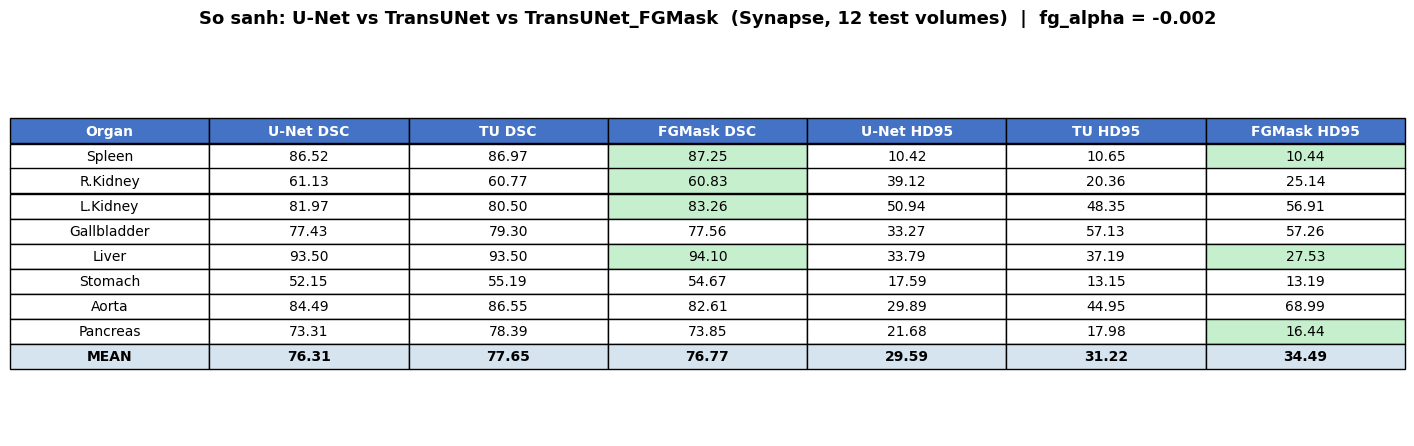

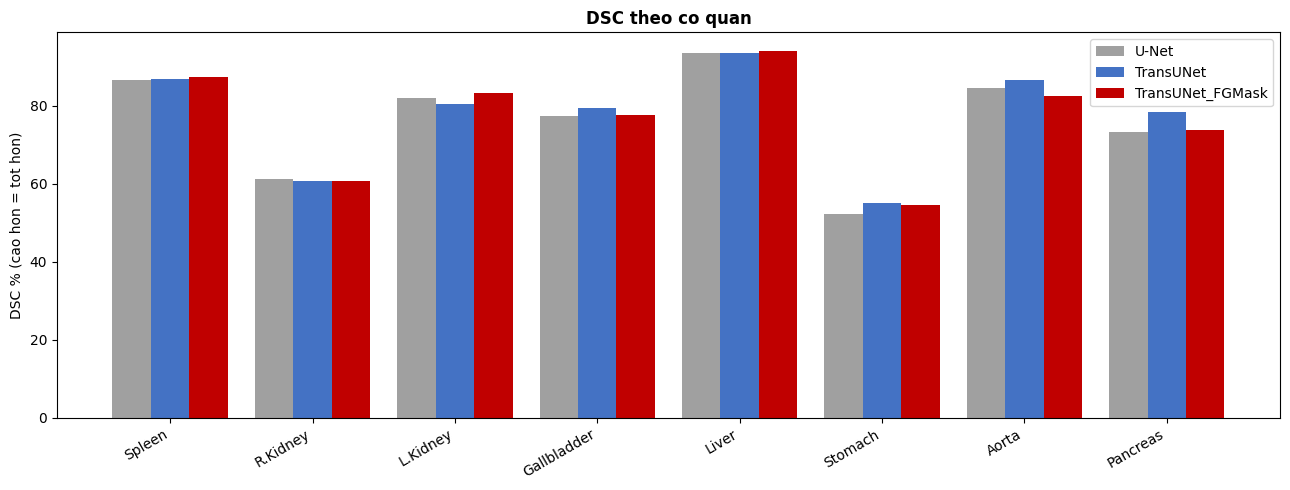

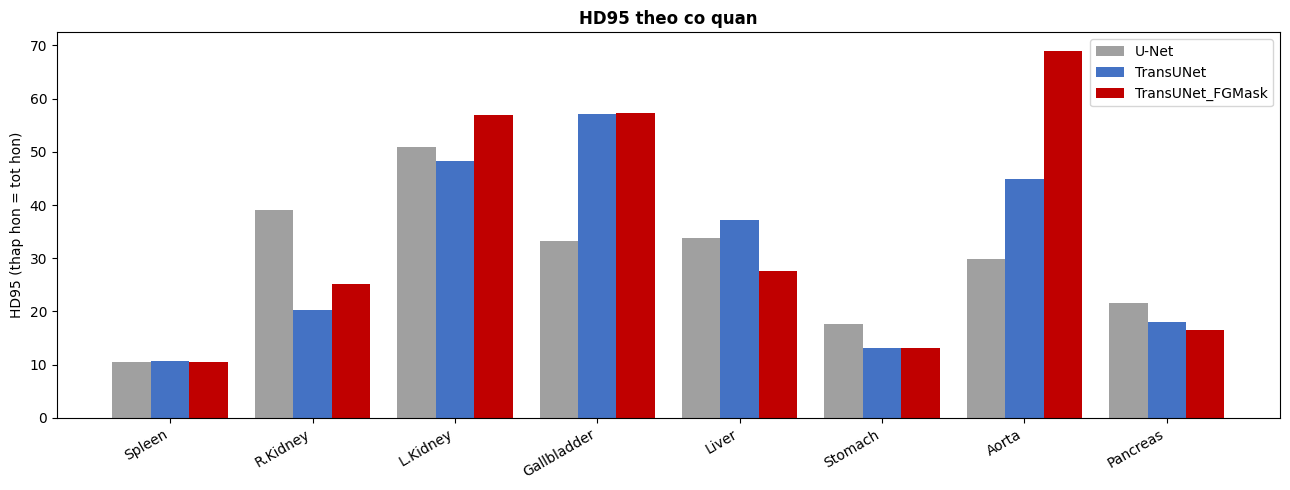

U-Net              : Mean DSC = 76.31%   Mean HD95 =  29.59
TransUNet (goc)    : Mean DSC = 77.65%   Mean HD95 =  31.22
TransUNet_FGMask   : Mean DSC = 76.77%   Mean HD95 =  34.49
FGMask vs TransUNet goc:  DSC -0.88%   |   HD95 +3.27
fg_alpha (learnable, final) = -0.0015   (0 = bo qua prior, cang lon = loc nen cang manh)
----------------------------------------------------------------
Co quan NHO (noi ky vong cai thien nhieu nhat):
  R.Kidney    : DSC 60.77 -> 60.83 (+0.06)   |  HD95 20.36 -> 25.14
  Gallbladder : DSC 79.30 -> 77.56 (-1.74)   |  HD95 57.13 -> 57.26
  Stomach     : DSC 55.19 -> 54.67 (-0.52)   |  HD95 13.15 -> 13.19
  Pancreas    : DSC 78.39 -> 73.85 (-4.54)   |  HD95 17.98 -> 16.44


In [8]:
import numpy as np
import matplotlib.pyplot as plt

ORGAN = ['Spleen', 'R.Kidney', 'L.Kidney', 'Gallbladder',
         'Liver', 'Stomach', 'Aorta', 'Pancreas']

# --- Baseline tu demo.ipynb (per-class, index = class Synapse 1..8) ---
tu_dice  = np.array([0.8697, 0.6077, 0.8050, 0.7930, 0.9350, 0.5519, 0.8655, 0.7839])
tu_hd95  = np.array([10.65, 20.36, 48.35, 57.13, 37.19, 13.15, 44.95, 17.98])
un_dice  = np.array([0.8652, 0.6113, 0.8197, 0.7743, 0.9350, 0.5215, 0.8449, 0.7331])
un_hd95  = np.array([10.42, 39.12, 50.94, 33.27, 33.79, 17.59, 29.89, 21.68])

# --- Ket qua FGMask vua train ---
m = np.load('/content/model/TU_FGMask_Synapse224/metrics.npy')  # (8,2): [dice, hd95]
fg_dice = m[:, 0]
fg_hd95 = m[:, 1]
try:
    alpha = float(np.load('/content/model/TU_FGMask_Synapse224/fg_alpha.npy')[0])
except Exception:
    alpha = float('nan')

# ============ BANG SO SANH ============
fig, ax = plt.subplots(figsize=(15, 5)); ax.axis('off')
cols = ['Organ', 'U-Net DSC', 'TU DSC', 'FGMask DSC',
        'U-Net HD95', 'TU HD95', 'FGMask HD95']
rows = []
for i in range(8):
    rows.append([ORGAN[i],
                 f'{un_dice[i]*100:.2f}', f'{tu_dice[i]*100:.2f}', f'{fg_dice[i]*100:.2f}',
                 f'{un_hd95[i]:.2f}', f'{tu_hd95[i]:.2f}', f'{fg_hd95[i]:.2f}'])
rows.append(['MEAN',
             f'{un_dice.mean()*100:.2f}', f'{tu_dice.mean()*100:.2f}', f'{fg_dice.mean()*100:.2f}',
             f'{un_hd95.mean():.2f}', f'{tu_hd95.mean():.2f}', f'{fg_hd95.mean():.2f}'])
tbl = ax.table(cellText=rows, colLabels=cols, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 1.5)
for j in range(len(cols)):
    tbl[0, j].set_facecolor('#4472C4'); tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[9, j].set_facecolor('#D6E4F0'); tbl[9, j].set_text_props(fontweight='bold')
# To xanh khi FGMask tot hon TransUNet goc
for i in range(8):
    if fg_dice[i] > tu_dice[i]: tbl[i+1, 3].set_facecolor('#C6EFCE')
    if fg_hd95[i] < tu_hd95[i]: tbl[i+1, 6].set_facecolor('#C6EFCE')
ax.set_title(f'So sanh: U-Net vs TransUNet vs TransUNet_FGMask  (Synapse, 12 test volumes)  |  fg_alpha = {alpha:.3f}',
             fontsize=13, fontweight='bold', pad=20)
import os; os.makedirs('/content/fgmask_output', exist_ok=True)
plt.savefig('/content/fgmask_output/compare_table.png', dpi=150, bbox_inches='tight'); plt.show()

# ============ BIEU DO DSC (tap trung co quan nho) ============
x = np.arange(8); wd = 0.27
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - wd, un_dice*100, wd, label='U-Net', color='#A0A0A0')
ax.bar(x,      tu_dice*100, wd, label='TransUNet', color='#4472C4')
ax.bar(x + wd, fg_dice*100, wd, label='TransUNet_FGMask', color='#C00000')
ax.set_xticks(x); ax.set_xticklabels(ORGAN, rotation=30, ha='right')
ax.set_ylabel('DSC % (cao hon = tot hon)')
ax.set_title('DSC theo co quan', fontweight='bold'); ax.legend()
plt.tight_layout()
plt.savefig('/content/fgmask_output/compare_dsc.png', dpi=150, bbox_inches='tight'); plt.show()

# ============ BIEU DO HD95 ============
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - wd, un_hd95, wd, label='U-Net', color='#A0A0A0')
ax.bar(x,      tu_hd95, wd, label='TransUNet', color='#4472C4')
ax.bar(x + wd, fg_hd95, wd, label='TransUNet_FGMask', color='#C00000')
ax.set_xticks(x); ax.set_xticklabels(ORGAN, rotation=30, ha='right')
ax.set_ylabel('HD95 (thap hon = tot hon)')
ax.set_title('HD95 theo co quan', fontweight='bold'); ax.legend()
plt.tight_layout()
plt.savefig('/content/fgmask_output/compare_hd95.png', dpi=150, bbox_inches='tight'); plt.show()

# ============ TONG KET ============
print('='*64)
print(f"U-Net              : Mean DSC = {un_dice.mean()*100:5.2f}%   Mean HD95 = {un_hd95.mean():6.2f}")
print(f"TransUNet (goc)    : Mean DSC = {tu_dice.mean()*100:5.2f}%   Mean HD95 = {tu_hd95.mean():6.2f}")
print(f"TransUNet_FGMask   : Mean DSC = {fg_dice.mean()*100:5.2f}%   Mean HD95 = {fg_hd95.mean():6.2f}")
print('='*64)
d_dsc  = (fg_dice.mean() - tu_dice.mean()) * 100
d_hd95 = fg_hd95.mean() - tu_hd95.mean()
print(f"FGMask vs TransUNet goc:  DSC {d_dsc:+.2f}%   |   HD95 {d_hd95:+.2f}")
print(f"fg_alpha (learnable, final) = {alpha:.4f}   (0 = bo qua prior, cang lon = loc nen cang manh)")
# Co quan nho: R.Kidney(2), Gallbladder(4), Stomach(6), Pancreas(8) -> index 1,3,5,7
small = [1, 3, 5, 7]
print('-'*64)
print('Co quan NHO (noi ky vong cai thien nhieu nhat):')
for i in small:
    print(f"  {ORGAN[i]:12s}: DSC {tu_dice[i]*100:5.2f} -> {fg_dice[i]*100:5.2f} "
          f"({(fg_dice[i]-tu_dice[i])*100:+.2f})   |  HD95 {tu_hd95[i]:5.2f} -> {fg_hd95[i]:5.2f}")
print('='*64)


## 6. Trực quan hoá Anatomy Prior Map & overlay dự đoán

Hai thứ minh hoạ trực tiếp ý tưởng:
1. **Prior Map `M`** mà `fg_prior` học được (heatmap 14×14 phóng to lên 224) — kỳ vọng sáng ở
   vùng cơ quan, tối ở nền. Đây là "bản đồ" mà attention dùng để bỏ qua Background.
2. **Overlay** CT | Ground Truth | TransUNet_FGMask cho vài lát cắt nhiều cơ quan.


/tmp/ipykernel_1483/3560367861.py:22: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print('fg_alpha =', float(net.transformer.fg_alpha))


fg_alpha = -0.00154270906932652


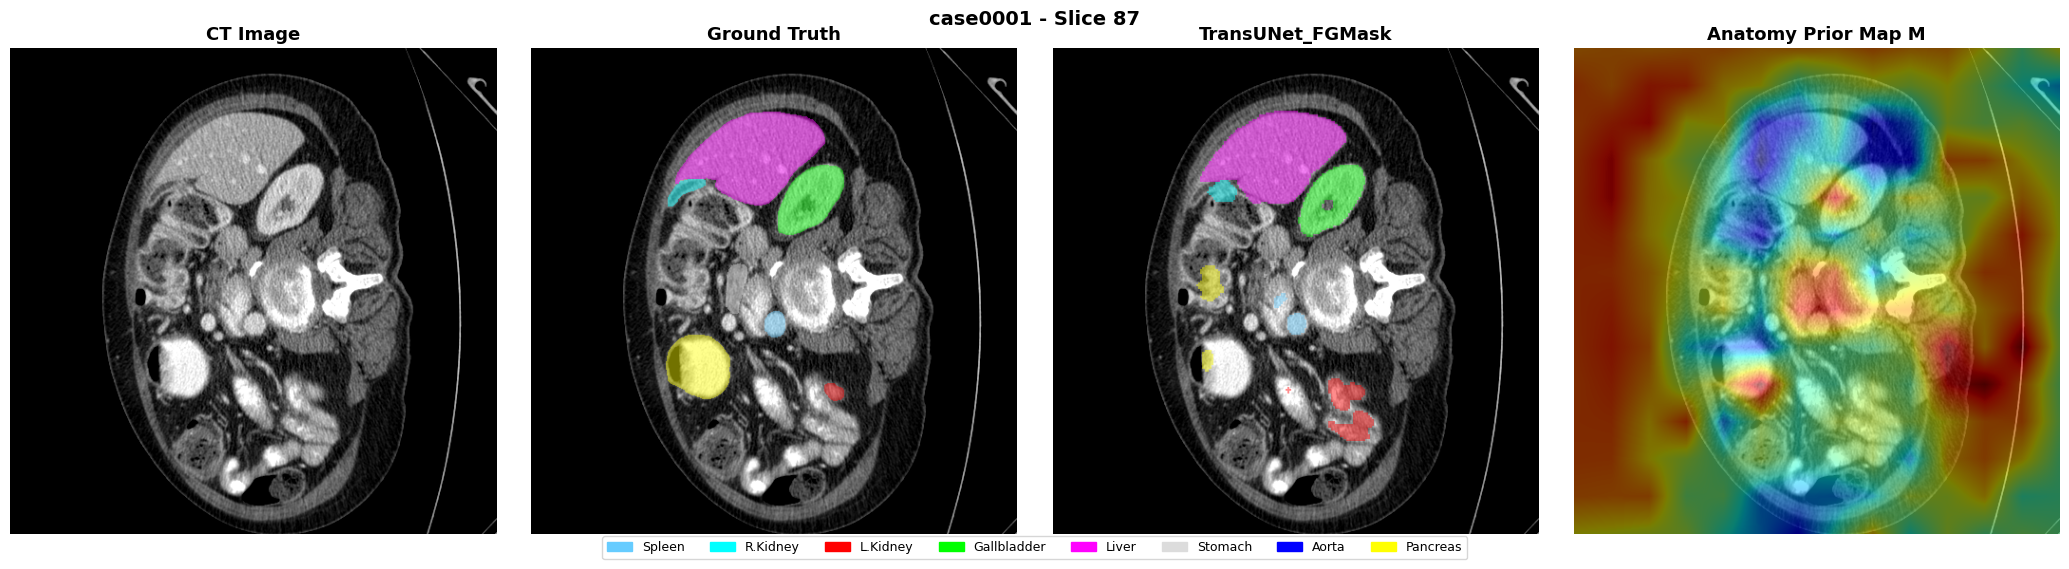

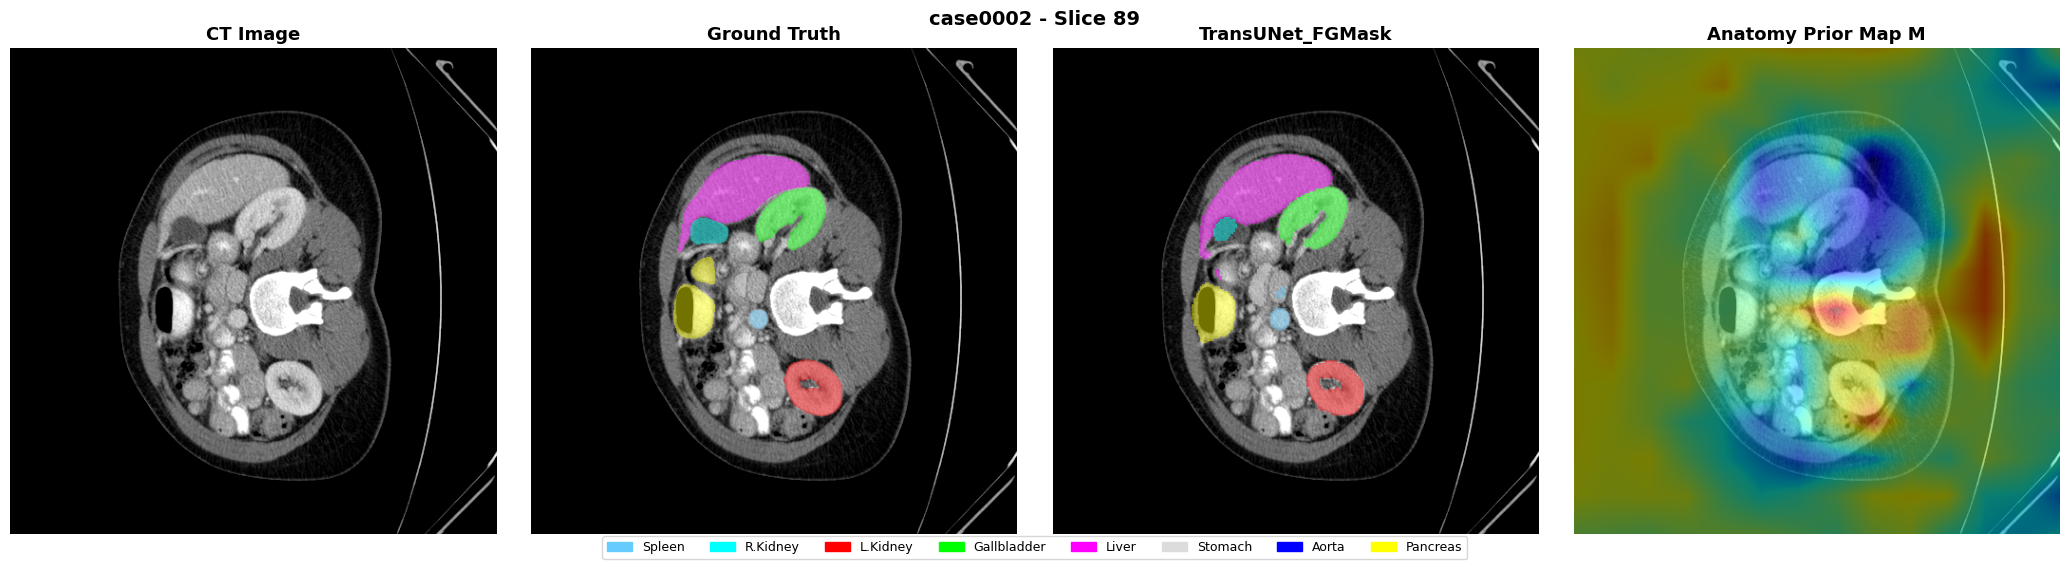

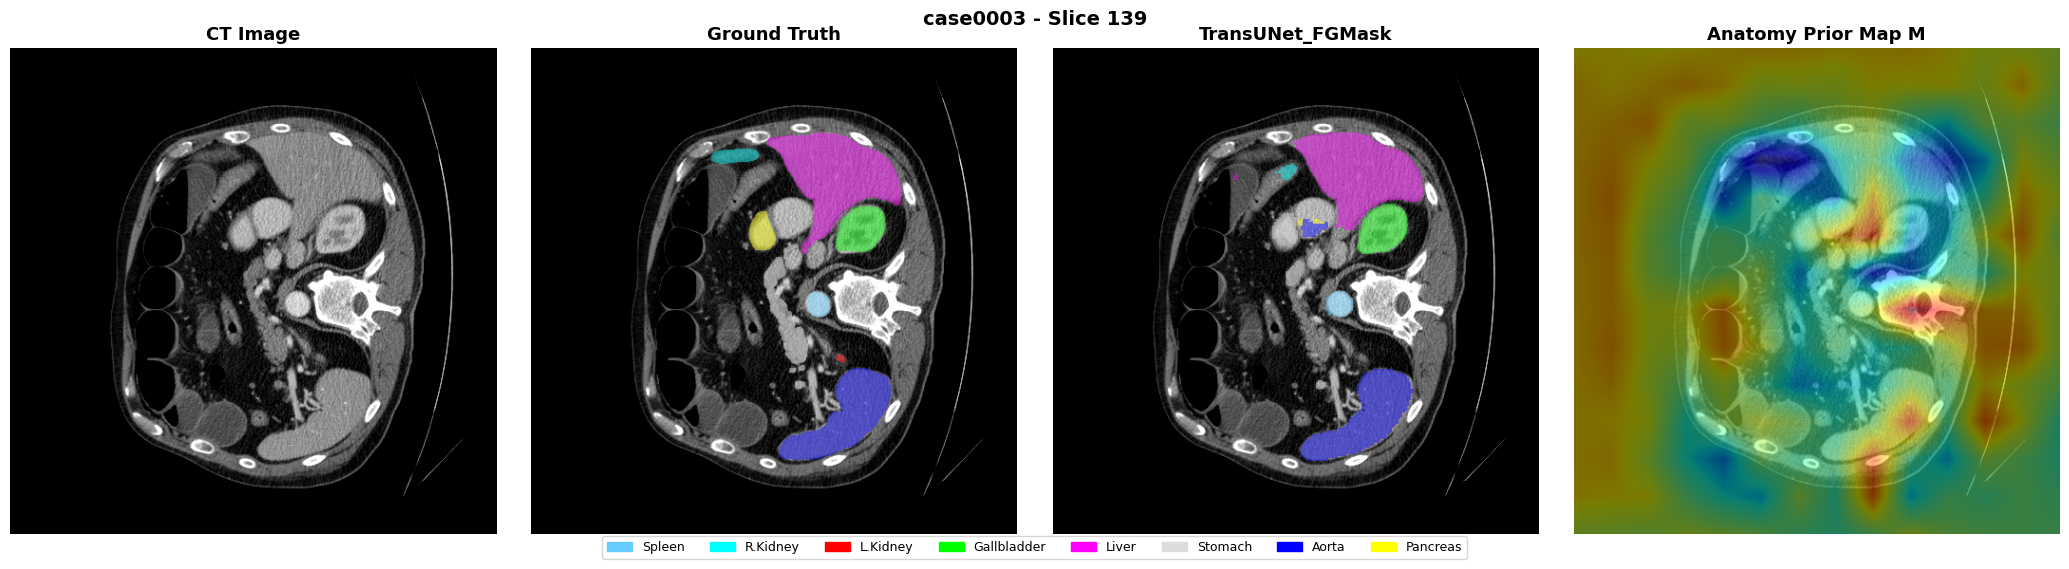

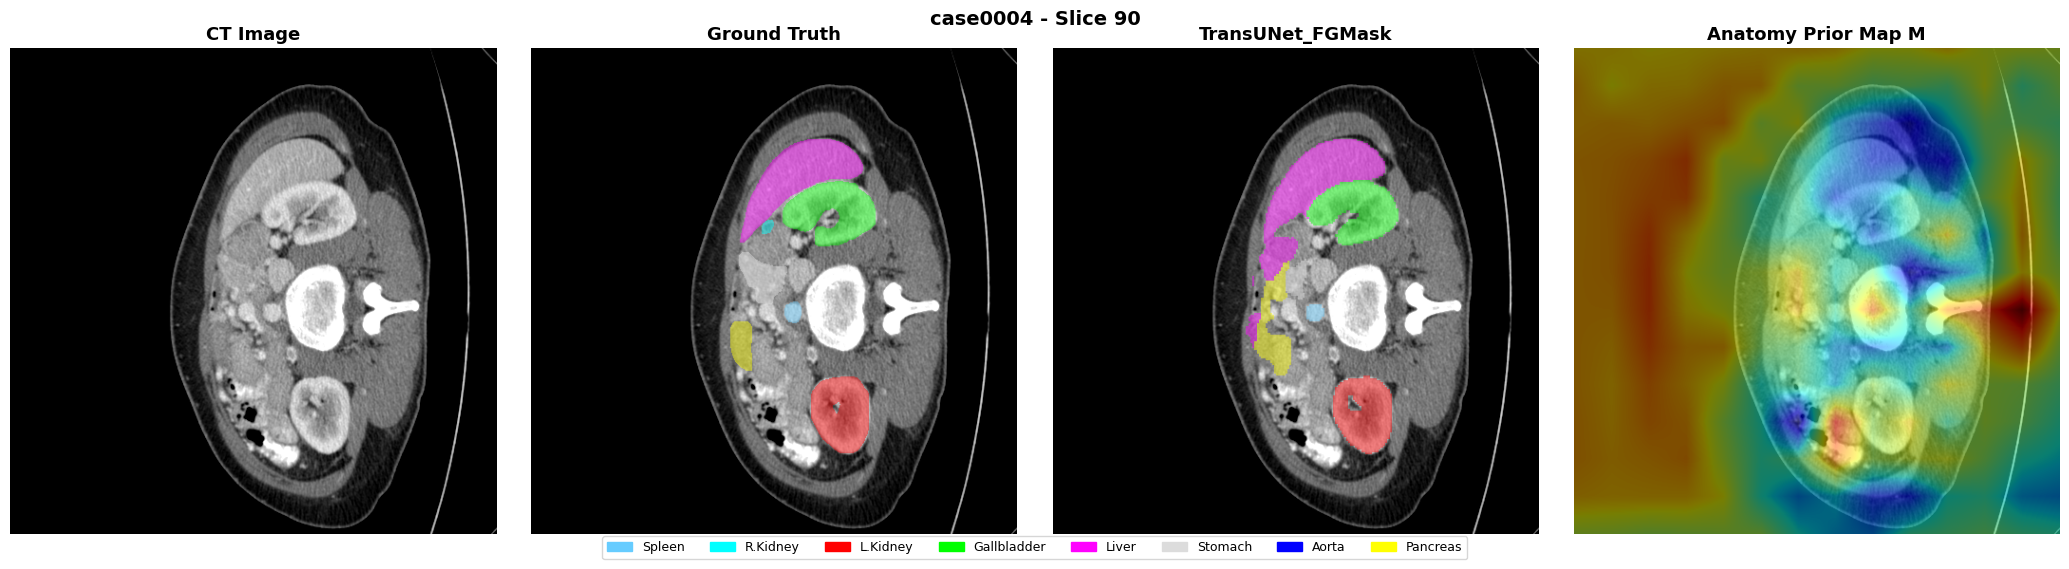

In [9]:
import os, sys, glob, h5py
import numpy as np, torch
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
from scipy.ndimage import zoom

sys.path.insert(0, '/content/TransUNet')
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg
from networks.vit_seg_fgmask import VisionTransformerFG

ORGAN = {1: 'Spleen', 2: 'R.Kidney', 3: 'L.Kidney', 4: 'Gallbladder',
         5: 'Liver', 6: 'Stomach', 7: 'Aorta', 8: 'Pancreas'}
CLR = np.array([[0,0,0],[102,204,255],[0,255,255],[255,0,0],[0,255,0],
                [255,0,255],[220,220,220],[0,0,255],[255,255,0]]) / 255.

config_vit = CONFIGS_ViT_seg['R50-ViT-B_16']
config_vit.n_classes = 9; config_vit.n_skip = 3; config_vit.patches.grid = (14, 14)
net = VisionTransformerFG(config_vit, img_size=224, num_classes=9).cuda()
_ckpt = sorted(glob.glob('/content/model/TU_FGMask_Synapse224/epoch_*.pth'),
               key=lambda p: int(p.split('epoch_')[-1].split('.pth')[0]))[-1]
net.load_state_dict(torch.load(_ckpt))
net.eval()
print('fg_alpha =', float(net.transformer.fg_alpha))

def predict_and_prior(slc):
    h, w = slc.shape
    s = zoom(slc, (224/h, 224/w), order=3) if (h != 224 or w != 224) else slc
    with torch.no_grad():
        inp = torch.from_numpy(s).unsqueeze(0).unsqueeze(0).float().cuda()
        o = net(inp)
        o = torch.argmax(torch.softmax(o, 1), 1).squeeze(0).cpu().numpy()
        # prior map M (14x14) vua duoc luu trong forward
        M = net.transformer.last_prior.squeeze(0).cpu().numpy().reshape(14, 14)
    pred = zoom(o, (h/224, w/224), order=0).astype(int) if (h != 224 or w != 224) else o.astype(int)
    M_up = zoom(M, (h/14, w/14), order=1)
    return pred, M_up

def overlay(img, lbl, a=0.45):
    im = (img - img.min()) / (img.max() - img.min() + 1e-8)
    rgb = np.stack([im]*3, -1).copy()
    for c in range(1, 9):
        msk = lbl == c
        if msk.any():
            for ch in range(3):
                rgb[:, :, ch][msk] = (1-a)*rgb[:, :, ch][msk] + a*CLR[c][ch]
    return np.clip(rgb, 0, 1)

out_dir = '/content/fgmask_output'; os.makedirs(out_dir, exist_ok=True)
test_dir = '/content/data/Synapse/test_vol_h5'
cases = sorted([f.replace('.npy.h5', '') for f in os.listdir(test_dir)])[:4]

for case in cases:
    data = h5py.File(os.path.join(test_dir, f'{case}.npy.h5'), 'r')
    imgs, lbls = data['image'][:], data['label'][:]
    n = imgs.shape[0]
    si = sorted(range(n), key=lambda s: -len(np.unique(lbls[s])))[0]
    gt = lbls[si].astype(int)
    pred, Mmap = predict_and_prior(imgs[si])
    im_n = (imgs[si] - imgs[si].min()) / (imgs[si].max() - imgs[si].min() + 1e-8)
    fig, ax = plt.subplots(1, 4, figsize=(21, 5.5))
    ax[0].imshow(im_n, cmap='gray'); ax[0].set_title('CT Image', fontsize=13, fontweight='bold')
    ax[1].imshow(overlay(imgs[si], gt)); ax[1].set_title('Ground Truth', fontsize=13, fontweight='bold')
    ax[2].imshow(overlay(imgs[si], pred)); ax[2].set_title('TransUNet_FGMask', fontsize=13, fontweight='bold')
    ax[3].imshow(im_n, cmap='gray'); ax[3].imshow(Mmap, cmap='jet', alpha=0.5)
    ax[3].set_title('Anatomy Prior Map M', fontsize=13, fontweight='bold')
    for a_ in ax: a_.axis('off')
    patches = [mpatches.Patch(color=CLR[i], label=ORGAN[i]) for i in range(1, 9)]
    fig.legend(handles=patches, loc='lower center', ncol=8, fontsize=9, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(f'{case} - Slice {si}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{out_dir}/{case}_s{si}.png', dpi=150, bbox_inches='tight'); plt.show()


In [10]:
# Dong goi ket qua de tai ve
!zip -r /content/fgmask_output.zip /content/fgmask_output/
from google.colab import files
files.download('/content/fgmask_output.zip')


  adding: content/fgmask_output/ (stored 0%)
  adding: content/fgmask_output/case0003_s139.png (deflated 2%)
  adding: content/fgmask_output/case0002_s89.png (deflated 3%)
  adding: content/fgmask_output/compare_table.png (deflated 13%)
  adding: content/fgmask_output/case0001_s87.png (deflated 2%)
  adding: content/fgmask_output/compare_hd95.png (deflated 22%)
  adding: content/fgmask_output/compare_dsc.png (deflated 22%)
  adding: content/fgmask_output/case0004_s90.png (deflated 3%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>